||f1|f2|y|
|:--|:--|:--|:--|
|$x^{(1)}$|3|6|1
|$x^{(2)}$|6|4|1
|$x^{(3)}$|8|2|3
|$x^{(4)}$|7|5|3
|$x^{(5)}$|1|4|2
|$x^{(6)}$|2|2|2

<img src=https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/040/474/original/Screenshot_2023-07-23_at_7.44.29_PM.png?1690130963 width=700>

1. **Step1:** We find the  **Euclidean distance between $x_q = [2,5]$ and all the training data.**


||f1|f2|y|$d^{(i)} = \sqrt{(x^q_{f1}-x^{(i)}_{f1})^2 + (x^q_{f2}-x^{(i)}_{f2})^2}$|
|:--|:--|:--|:--|:--|
|$x^{(1)}$|3|6|1|$\sqrt{(1^2 + 1^2)} = 1.41$|
|$x^{(2)}$|6|4|1|$\sqrt{(4^2 + 1^2)} = 3.00$|
|$x^{(3)}$|8|2|3|$\sqrt{(6^2 + 3^2)} = 6.48$|
|$x^{(4)}$|7|5|3|$\sqrt{(5^2 + 0^2)} = 5.00$|
|$x^{(5)}$|1|4|2|$\sqrt{(1^2 + 1^2)} = 1.41$|
|$x^{(6)}$|2|2|2|$\sqrt{(0^2 + 2^2)} = 2.00$|



  

<img src=https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/040/475/original/Screenshot_2023-07-23_at_7.44.37_PM.png?1690130998 width=700>

<img src=https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/040/476/original/Screenshot_2023-07-23_at_7.44.47_PM.png?1690131021 width=700>

In [2]:
import pandas as pd
import numpy as np

In [ ]:
!gdown 1ZdhRqYv-JizWV6DxO6C4R_k1kxPhmlF2


Downloading...
From: https://drive.google.com/uc?id=1ZdhRqYv-JizWV6DxO6C4R_k1kxPhmlF2
To: /content/multiclass.csv
100% 14.6k/14.6k [00:00<00:00, 31.8MB/s]


In [3]:
df=pd.read_csv('multiclass.csv')
df.head()

,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,class
0,3,12669,9656,7561,214,2674,1338,2
1,3,7057,9810,9568,1762,3293,1776,2
2,3,6353,8808,7684,2405,3516,7844,2
3,3,13265,1196,4221,6404,507,1788,1
4,3,22615,5410,7198,3915,1777,5185,1


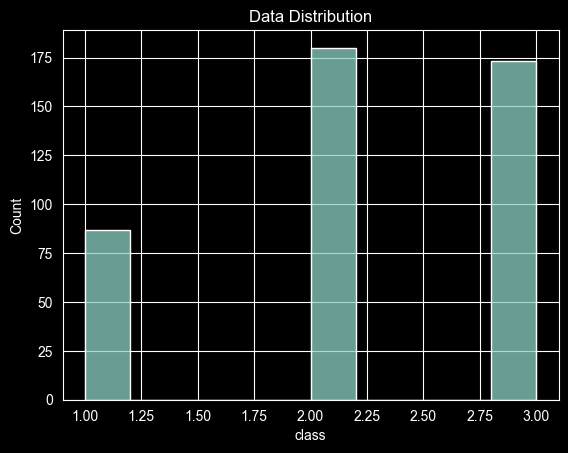

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=df, x="class")
plt.title('Data Distribution')
plt.show()

In [5]:
X=df[['Region',	'Fresh',	'Milk',	'Grocery',	'Frozen',	'Detergents_Paper',	'Delicassen'	]].copy()
y=df[['class']].copy()

In [6]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


def scatter_visualize(visualize1,visualize2,y_label):
  scatter = plt.scatter(visualize[:,0] ,visualize[:,1],c = y.values[:,0] )
  plt.legend(handles=scatter.legend_elements()[0], labels=['Class1','Class2','Class3'])
  plt.show()

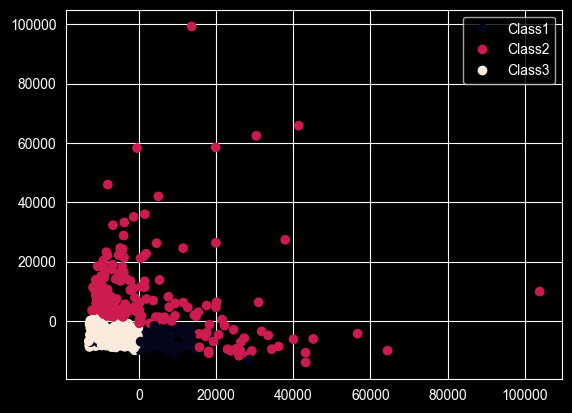

In [7]:
pca = PCA(n_components=2)
visualize = pca.fit_transform(X)


scatter_visualize(visualize[:,0] ,visualize[:,1],y.values[:,0])

In [8]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

X_train_val, X_test, y_train_val, y_test = train_test_split(X,y,test_size=0.25, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_train_val,y_train_val,test_size=0.25, random_state=42)

In [9]:
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(247, 7) (247, 1)
(83, 7) (83, 1)
(110, 7) (110, 1)


In [10]:
from sklearn.preprocessing import StandardScaler

st =  StandardScaler()

X_sm = st.fit_transform(X_train.values)
X_val_scaled = st.transform(X_val.values)
X_test_scaled = st.transform(X_test.values)

y_sm = y_train.values[:,0]
y_val = y_val.values[:,0]
y_test = y_test.values[:,0]

In [11]:
y_val

array([3, 2, 2, 2, 3, 2, 3, 2, 3, 3, 2, 2, 1, 3, 2, 3, 3, 3, 3, 1, 1, 1,
       2, 2, 1, 2, 3, 2, 2, 2, 2, 3, 2, 2, 2, 3, 2, 1, 3, 3, 3, 3, 1, 2,
       3, 2, 2, 3, 2, 3, 3, 2, 3, 3, 2, 2, 3, 3, 3, 1, 1, 2, 1, 1, 3, 2,
       2, 1, 3, 2, 2, 2, 2, 2, 3, 2, 1, 3, 1, 2, 3, 2, 2])

In [12]:
X_val_scaled[50]

array([ 0.65073249, -0.49151135, -0.48436111, -0.6888578 , -0.29269993,
       -0.54361718, -0.26957321])

In [13]:
dist = np.sqrt(np.sum((X_val_scaled[50]-X_sm)**2,axis=1) )

print(dist.shape)

(247,)


In [14]:
# Storing distance and Class labels together
distances = [(dist[i],y_sm[i]) for i in range(len(dist)) ]

# sort the distances
distances = sorted(distances)

In [15]:
distances = distances[:5]

In [ ]:
distances

[(np.float64(0.19275661488858367), np.int64(3)),
 (np.float64(0.2027784716985357), np.int64(3)),
 (np.float64(0.2159416502390324), np.int64(3)),
 (np.float64(0.2673329164659889), np.int64(3)),
 (np.float64(0.28247298555212313), np.int64(3))]

In [ ]:
distances = np.array(distances)


In [ ]:
distances

array([[0.19275661, 3.        ],
       [0.20277847, 3.        ],
       [0.21594165, 3.        ],
       [0.26733292, 3.        ],
       [0.28247299, 3.        ]])

In [ ]:
classes_counts = np.unique(distances[:,1],return_counts=True)


In [ ]:
classes_counts

(array([3.]), array([5]))

In [ ]:
distances[:,1]

array([3., 3., 3., 3., 3.])

In [ ]:
index = classes_counts[1].argmax()


In [ ]:
pred = classes_counts[0][index]


In [ ]:
pred

np.float64(3.0)

In [ ]:
def knn(X,Y,queryPoint,k):
    """Predict the class label for the query point"""
    # Euclidean Distance
    dist = np.sqrt(np.sum((queryPoint-X)**2,axis=1) )

    # Storing distance and Class labels together
    distances = [(dist[i],Y[i]) for i in range(len(dist)) ]
    # sort the distances
    distances = sorted(distances)
    # Nearest/First K points
    distances = distances[:k]

    distances = np.array(distances)

    classes_counts = np.unique(distances[:,1],return_counts=True)

    index = classes_counts[1].argmax()
    pred = classes_counts[0][index]

    return int(pred),distances

In [ ]:
pred,neighbors = knn(X_sm, y_sm, X_val_scaled[50],5)

print(f'k nearest neighbors with the distance and class label :{neighbors}')

print(f'The predicted class label: {pred}')

k nearest neighbors with the distance and class label :[[0.19275661 3.        ]
 [0.20277847 3.        ]
 [0.21594165 3.        ]
 [0.26733292 3.        ]
 [0.28247299 3.        ]]
The predicted class label: 3


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5,metric='euclidean')

knn.fit(X_sm, y_sm)

KNeighborsClassifier(metric='euclidean')

In [ ]:
knn.score(X_val_scaled, y_val)

0.9156626506024096

In [ ]:
from sklearn.metrics import classification_report

y_pred = knn.predict(X_val_scaled)
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           1       0.85      0.79      0.81        14
           2       0.97      0.92      0.95        38
           3       0.88      0.97      0.92        31

    accuracy                           0.92        83
   macro avg       0.90      0.89      0.89        83
weighted avg       0.92      0.92      0.92        83



In [ ]:
!gdown 1vDIXh1yJxLpmgdh3gZGM6WX0u3GCPuIS


Downloading...
From: https://drive.google.com/uc?id=1vDIXh1yJxLpmgdh3gZGM6WX0u3GCPuIS
To: /content/knn_imputation.csv
100% 12.9k/12.9k [00:00<00:00, 26.1MB/s]


In [16]:
import pandas as pd
import numpy as np

df_imp = pd.read_csv('knn_imputation.csv')
df_imp.drop(['Unnamed: 0'],axis=1,inplace=True)

In [17]:
df_imp.head()

,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,3.0,12669.0,9656.0,7561.0,214.0,2674.0,1338.0
1,3.0,7057.0,9810.0,9568.0,1762.0,3293.0,1776.0
2,3.0,6353.0,8808.0,NaN,2405.0,3516.0,7844.0
3,3.0,13265.0,1196.0,4221.0,6404.0,507.0,1788.0
4,3.0,22615.0,5410.0,7198.0,3915.0,1777.0,5185.0


In [18]:
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

# Create the pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Step 1: StandardScaler for feature scaling
    ('imputer', KNNImputer(n_neighbors=5))  # Step 2: KNNImputer for missing value imputation
])

# Fit and transform the data using the pipeline
X_transformed = pipeline.fit_transform(df_imp)

# Creating dataframe
X_transformed = pd.DataFrame(X_transformed,columns=df_imp.columns)

/Users/kishankunal/workspace/AppliedAI/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kishankunal/workspace/AppliedAI/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kishankunal/workspace/AppliedAI/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [19]:
X_transformed.head()

,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,0.555438,-0.233395,0.187310,-0.319038,-0.554681,-0.272830,-0.175386
1,0.555438,-0.616431,0.204632,-0.139260,-0.281917,-0.165147,-0.051741
2,0.555438,-0.664481,0.091925,0.200717,-0.168617,-0.126353,1.661231
3,0.555438,-0.192716,-0.764292,-0.618222,0.536025,-0.649809,-0.048353
4,0.555438,0.445450,-0.290291,-0.351554,0.097452,-0.428875,0.910606
